# Overfit - Generalized - Underfit

In [1]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
data, target = housing.data, housing.target
target *= 100  # rescale the target in k$

In [2]:
from sklearn.tree import DecisionTreeRegressor

regressor = DecisionTreeRegressor()

In [3]:
import pandas as pd
from sklearn.model_selection import cross_validate, ShuffleSplit

cv = ShuffleSplit(n_splits=30, test_size=0.2, random_state=0)
cv_results = cross_validate(
    regressor,
    data,
    target,
    cv=cv,
    scoring="neg_mean_absolute_error",
    return_train_score=True,
    n_jobs=2,
)
cv_results = pd.DataFrame(cv_results)

In [4]:
scores = pd.DataFrame()
scores[["train error", "test error"]] = -cv_results[
    ["train_score", "test_score"]
]

In [6]:
scores.head()

,train error,test error
0,1.551214e-14,47.085314
1,3.401241e-15,46.750070
2,9.322431e-15,44.513294
3,1.270990e-14,44.047834
4,8.812933e-15,48.376572


In [8]:
cv_results.head()

,fit_time,score_time,test_score,train_score
0,0.323746,0.004690,-47.085314,-1.551214e-14
1,0.339787,0.004515,-46.750070,-3.401241e-15
2,0.273734,0.003646,-44.513294,-9.322431e-15
3,0.284615,0.004101,-44.047834,-1.270990e-14
4,0.339869,0.004165,-48.376572,-8.812933e-15


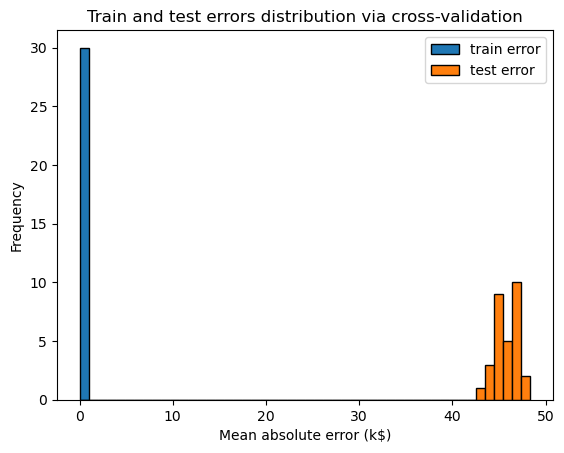

In [9]:
import matplotlib.pyplot as plt

scores.plot.hist(bins=50, edgecolor="black")
plt.xlabel("Mean absolute error (k$)")
_ = plt.title("Train and test errors distribution via cross-validation")

- Small training error implies that model is not underfitting
- Large test error implies that model is overfitted

---
- Tuning the hyperparameters can control the trade off between under and over fitting
- `max_depth` parameter is used to control the tradeoff

CPU times: total: 172 ms
Wall time: 26 s


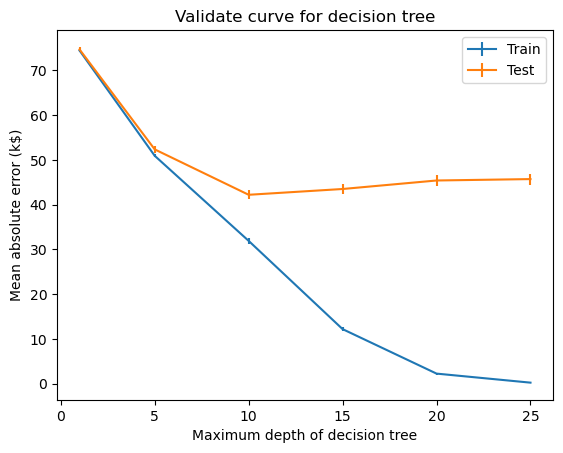

In [10]:
%%time
import numpy as np
from sklearn.model_selection import ValidationCurveDisplay

max_depth = np.array([1, 5, 10, 15, 20, 25])
disp = ValidationCurveDisplay.from_estimator(
    regressor,
    data,
    target,
    param_name="max_depth",
    param_range=max_depth,
    cv=cv,
    scoring="neg_mean_absolute_error",
    negate_score=True,
    std_display_style="errorbar",
    n_jobs=2,
)
_ = disp.ax_.set(
    xlabel="Maximum depth of decision tree",
    ylabel="Mean absolute error (k$)",
    title="Validate curve for decision tree",
)

**Observations :**
- for max_depth < 10 , model underfits as both the errors are high
- for max_depth > 10 model overfits as training error is low but test error is high
- max_depth = 10 is the parameter for which decision tree fits (genrealizes) the best